100%|██████████| 170M/170M [31:10<00:00, 91.2kB/s]


Device: cpu
Epoch 1/10, Loss: 1.4240
Epoch 2/10, Loss: 1.1033
Epoch 3/10, Loss: 0.9587
Epoch 4/10, Loss: 0.8573
Epoch 5/10, Loss: 0.7737
Epoch 6/10, Loss: 0.6949
Epoch 7/10, Loss: 0.6291
Epoch 8/10, Loss: 0.5622
Epoch 9/10, Loss: 0.5030
Epoch 10/10, Loss: 0.4412

Accuracy on test data: 70.30%


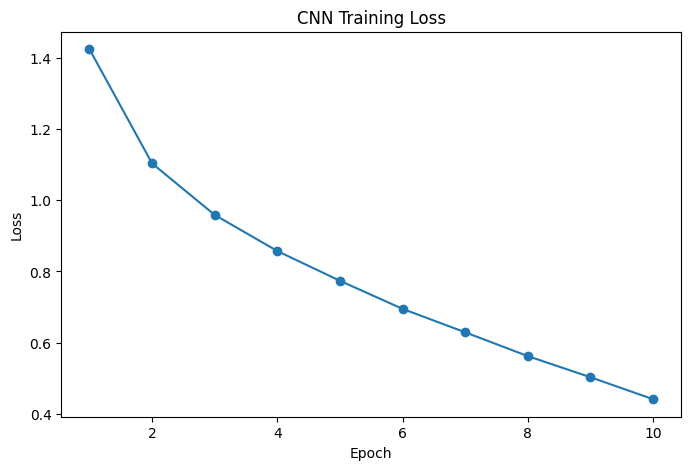

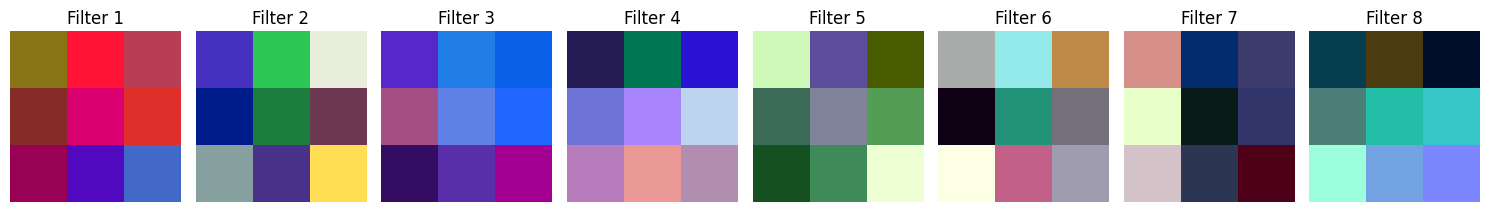

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

classes = trainset.classes

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 32 * 8 * 8)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

model = SimpleCNN().to(device)

lossfn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

losses = []

for epoch in range(epochs):

    running_loss = 0.0

    for inputs, labels in trainloader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = lossfn(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)

    losses.append(epoch_loss)

    print(
        f"Epoch {epoch + 1}/10, Loss: {epoch_loss:.4f}"
    )

correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"\nAccuracy on test data: {accuracy:.2f}%")

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    losses,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")

plt.show()

def visualize_filters(layer, n_filters=8):

    filters = layer.weight.data.clone().cpu()

    fig, axs = plt.subplots(
        1,
        n_filters,
        figsize=(15, 4)
    )

    for i in range(n_filters):

        f = filters[i]

        f = (f - f.min()) / (
            f.max() - f.min() + 1e-8
        )

        axs[i].imshow(
            f.permute(1, 2, 0)
        )

        axs[i].axis('off')

        axs[i].set_title(
            f'Filter {i + 1}'
        )

    plt.tight_layout()

    plt.show()

visualize_filters(model.conv1)